In [1]:
import math
import matplotlib.pyplot as plt

def generate_geometric_layout(nodes, song_columns):
    coords = {}
    
    # --- 1. Word 节点 (左侧直线) ---
    word_nodes = sorted([n for n in nodes if n['type'] == 'word'], key=lambda x: x['degree'], reverse=True)
    y_gap = 25
    word_x_cols = [120, 0] # 靠近中心的在 x=120
    
    mid = (len(word_nodes) + 1) // 2
    for i, node in enumerate(word_nodes):
        col_idx = 0 if i < mid else 1
        inner_idx = i if col_idx == 0 else i - mid
        
        # 垂直排布：0, 1, -1, 2, -2...
        rank = (inner_idx + 1) // 2
        direction = 1 if inner_idx % 2 != 0 else -1
        if inner_idx == 0: direction = 0
        
        x = word_x_cols[col_idx]
        y = (rank * direction * y_gap) + (col_idx * 15) # 15为列间错位
        coords[node['id']] = (x, y)

    # --- 2. Song 节点 (同心圆弧) ---
    # 定义每条弧线的几何参数
    # radii: 半径, angle_spans: 张角范围(弧度)
    arc_configs = [
        {"r": 400, "span": math.pi / 1.8}, 
        {"r": 600, "span": math.pi / 1.6}, 
        {"r": 800, "span": math.pi / 1.4}, 
    ]
    
    center_x = 400 # 圆心 X 坐标
    song_stagger = 30 # 列纵向错位

    for col_idx, col_ids in enumerate(song_columns[:3]):
        config = arc_configs[col_idx]
        radius = config["r"]
        half_span = config["span"] / 2
        num_in_col = len(col_ids)
        
        if num_in_col == 0: continue

        for row_idx, s_id in enumerate(col_ids):
            # 角度从 +half_span (顶部) 到 -half_span (底部)
            if num_in_col > 1:
                angle = half_span - (row_idx / (num_in_col - 1)) * (2 * half_span)
            else:
                angle = 0
            
            # 计算同心圆坐标
            x = center_x + radius * math.cos(angle)
            y = radius * math.sin(angle) + (col_idx * song_stagger)
            coords[s_id] = (round(x, 2), round(y, 2))
            
    return coords




pos = generate_geometric_layout(nodes_subset, song_cols)

# --- 绘图预览 ---
plt.figure(figsize=(10, 10))
ax = plt.gca()

# 区分绘制
for n_type, color, size in [('word', '#e74c3c', 30), ('song', '#3498db', 15)]:
    ids = [n['id'] for n in nodes_subset if n['type'] == n_type]
    plt.scatter([pos[i][0] for i in ids], [pos[i][1] for i in ids], c=color, s=size, alpha=0.8)



plt.title("Concentric Arc Layout (Fixed Spans)")
plt.axis('equal')
plt.axis('off')
plt.show()

NameError: name 'nodes_subset' is not defined

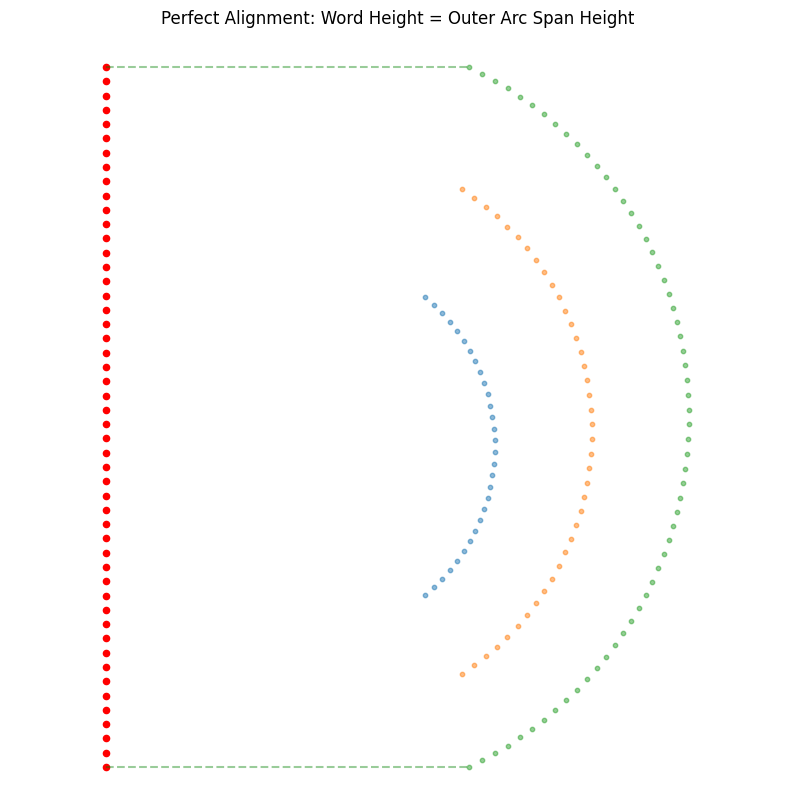

In [103]:
import math
import matplotlib.pyplot as plt

def generate_perfect_aligned_layout(nodes, song_columns):
    coords = {}
    
    # --- 1. 定义弧线配置 (最右侧弧线索引为2) ---
    arc_configs = [
        {"r": 400, "span": math.pi / 1.8}, 
        {"r": 600, "span": math.pi / 1.6}, 
        {"r": 800, "span": math.pi / 1.4}, 
    ]
    
    # 计算最外层弧线的垂直端点坐标 (y = r * sin(span/2))
    outer_arc = arc_configs[2]
    # 这是最右侧弧线顶点的绝对 Y 值
    outer_y_limit = outer_arc["r"] * math.sin(outer_arc["span"] / 2)
    
    # --- 2. Word 节点 (左侧单列) ---
    word_nodes = sorted([n for n in nodes if n['type'] == 'word'], key=lambda x: x['degree'], reverse=True)
    num_words = len(word_nodes)
    
    # 为了让 Word 节点从上到下排列，且首末点对齐弧线顶点
    # 总跨度为 2 * outer_y_limit
    if num_words > 1:
        # y 坐标从 +outer_y_limit 均匀减小到 -outer_y_limit
        for i, node in enumerate(word_nodes):
            # 线性插值计算 Y
            y = outer_y_limit - (i / (num_words - 1)) * (2 * outer_y_limit)
            coords[node['id']] = (0, round(y, 2))
    else:
        coords[word_nodes[0]['id']] = (0, 0)

    # --- 3. Song 节点 (同心圆弧) ---
    center_x = 400 
    # 注意：为了绝对对齐，我们要么取消 song_stagger，要么让 Word 跟着偏移
    # 这里我们保持 song_stagger，但为了对齐最右侧，让 word 偏移到与最右侧弧线一致
    final_stagger = 2 * 30 # 最右侧弧线的偏移量 (col_idx * song_stagger)
    
    # 修正 Word 坐标，使其加上偏移量
    for n in word_nodes:
        old_x, old_y = coords[n['id']]
        coords[n['id']] = (old_x, old_y + final_stagger)

    for col_idx, col_ids in enumerate(song_columns[:3]):
        config = arc_configs[col_idx]
        radius = config["r"]
        half_span = config["span"] / 2
        num_in_col = len(col_ids)
        
        # 每一列的垂直偏移
        current_col_offset = col_idx * 30 

        for row_idx, s_id in enumerate(col_ids):
            if num_in_col > 1:
                # 角度从 +half_span 变到 -half_span
                angle = half_span - (row_idx / (num_in_col - 1)) * (2 * half_span)
            else:
                angle = 0
            
            x = center_x + radius * math.cos(angle)
            y = radius * math.sin(angle) + current_col_offset
            coords[s_id] = (round(x, 2), round(y, 2))
            
    return coords

# --- 测试数据 ---
test_nodes = [{'id': f'W{i}', 'type': 'word', 'degree': 100-i} for i in range(50)] + \
             [{'id': f'S{i}', 'type': 'song', 'degree': 5} for i in range(130)]
s_ids = [n['id'] for n in test_nodes if n['type']=='song']
song_cols = [s_ids[0:30], s_ids[30:70], s_ids[70:130]]

pos = generate_perfect_aligned_layout(test_nodes, song_cols)

# --- 绘图验证 ---
plt.figure(figsize=(10, 10))
# 绘制 Word (红)
w_ids = [n['id'] for n in test_nodes if n['type']=='word']
plt.scatter([pos[i][0] for i in w_ids], [pos[i][1] for i in w_ids], c='red', s=20)

# 绘制 Song (蓝)
for col_idx, col_ids in enumerate(song_cols):
    plt.scatter([pos[i][0] for i in col_ids], [pos[i][1] for i in col_ids], s=10, alpha=0.5)

# 绘制两条绿色的水平对齐线，连接 Word 的端点和最外层弧线的端点
top_y = max([pos[i][1] for i in song_cols[2]])
bottom_y = min([pos[i][1] for i in song_cols[2]])
plt.plot([0, pos[song_cols[2][0]][0]], [top_y, top_y], 'g--', alpha=0.4)
plt.plot([0, pos[song_cols[2][-1]][0]], [bottom_y, bottom_y], 'g--', alpha=0.4)

plt.title("Perfect Alignment: Word Height = Outer Arc Span Height")
plt.axis('equal')
plt.axis('off')
plt.show()

In [115]:
pos = generate_degree_centered_layout(nodes_subset, song_cols)

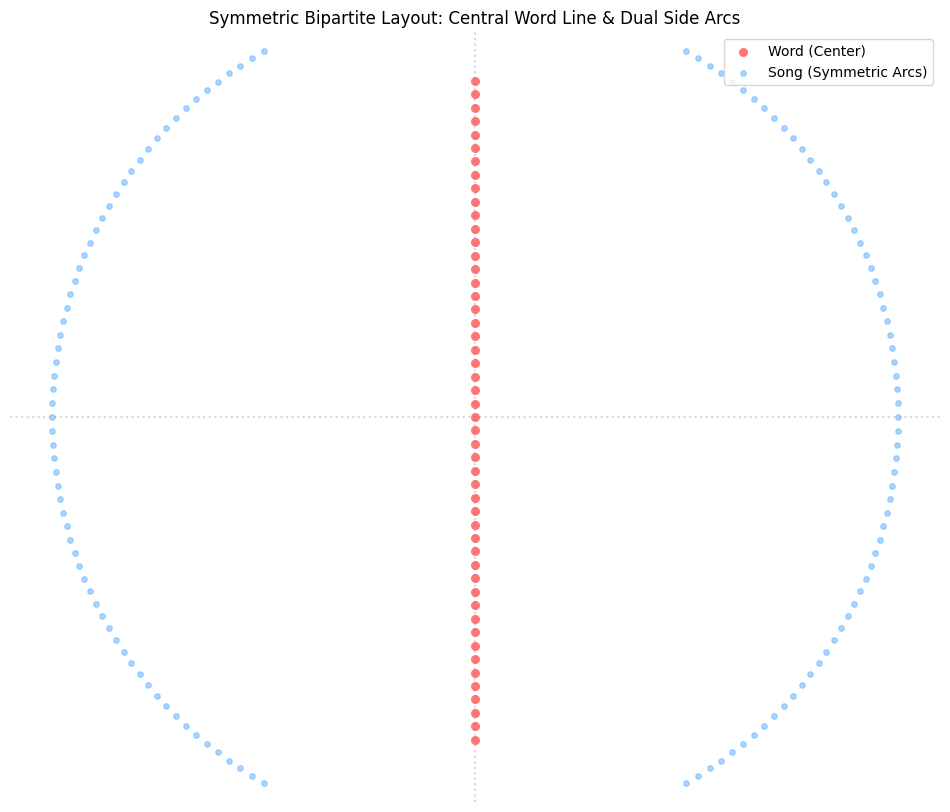

In [3]:
import math
import matplotlib.pyplot as plt

def generate_symmetric_bipartite_layout(nodes):
    coords = {}
    
    # --- 1. 参数定义 ---
    # 定义两条对称弧线的几何参数
    arc_radius = 800
    arc_span = math.pi / 1.5  # 约 120 度
    # 计算弧线的垂直跨度 (用于决定 Word 长度)
    arc_vertical_span = 2 * arc_radius * math.sin(arc_span / 2)
    
    # --- 2. Word 节点 (画布中央直线) ---
    word_nodes = sorted([n for n in nodes if n['type'] == 'word'], key=lambda x: x['degree'], reverse=True)
    num_words = len(word_nodes)
    
    # 长度为弧线跨度的 90%
    target_word_height = arc_vertical_span * 0.9
    word_y_gap = target_word_height / (num_words - 1) if num_words > 1 else 0

    for i, node in enumerate(word_nodes):
        # 中心向两端扩散逻辑: 0->0, 1->1, 2->-1, 3->2...
        rank = (i + 1) // 2
        direction = 1 if i % 2 != 0 else -1
        if i == 0: direction = 0
        
        # Word 位于 x=0，且在 y 轴居中
        coords[node['id']] = (0, round(rank * direction * word_y_gap, 2))

    # --- 3. Song 节点 (两侧对称弧线) ---
    song_nodes = [n for n in nodes if n['type'] == 'song']
    mid_idx = len(song_nodes) // 2
    # 将 Song 平均分为两组：左侧弧和右侧弧
    song_columns = [song_nodes[:mid_idx], song_nodes[mid_idx:]]
    
    # 弧线布局配置：[左侧弧, 右侧弧]
    # 左侧弧圆心在正 X，向左弯曲；右侧弧圆心在负 X，向右弯曲
    configs = [
        {"center_x": 0, "direction": -1}, # 右侧弧 (位于 Word 右侧)
        {"center_x": 0, "direction": 1}  # 左侧弧 (位于 Word 左侧)
    ]

    for col_idx, col_items in enumerate(song_columns):
        config = configs[col_idx]
        num_in_col = len(col_items)
        if num_in_col == 0: continue
        
        for row_idx, node in enumerate(col_items):
            # 从上到下均匀分布角度
            if num_in_col > 1:
                angle = (arc_span / 2) - (row_idx / (num_in_col - 1)) * arc_span
            else:
                angle = 0
            
            # 计算坐标
            # cos(angle) 决定 X 偏移，direction 决定是在圆心左侧还是右侧
            x = config["center_x"] + config["direction"] * (arc_radius * math.cos(angle))
            y = arc_radius * math.sin(angle)
            coords[node['id']] = (round(x, 2), round(y, 2))
            
    return coords

# --- 模拟数据 ---
test_nodes = [{'id': f'W{i}', 'type': 'word', 'degree': 100-i} for i in range(50)] + \
             [{'id': f'S{i}', 'type': 'song', 'degree': 5} for i in range(130)]

pos = generate_symmetric_bipartite_layout(test_nodes)

# --- 绘图预览 ---
plt.figure(figsize=(12, 10))

# 绘制 Word (红色)
w_ids = [n['id'] for n in test_nodes if n['type']=='word']
plt.scatter([pos[i][0] for i in w_ids], [pos[i][1] for i in w_ids], c='#ff7675', s=30, label='Word (Center)')

# 绘制 Song (蓝色)
s_ids = [n['id'] for n in test_nodes if n['type']=='song']
plt.scatter([pos[i][0] for i in s_ids], [pos[i][1] for i in s_ids], c='#74b9ff', s=15, alpha=0.6, label='Song (Symmetric Arcs)')

# 绘制对齐参考线
plt.axhline(y=0, color='gray', linestyle=':', alpha=0.3)
plt.axvline(x=0, color='gray', linestyle=':', alpha=0.3)

plt.title("Symmetric Bipartite Layout: Central Word Line & Dual Side Arcs")
plt.axis('equal')
plt.axis('off')
plt.legend()
plt.show()

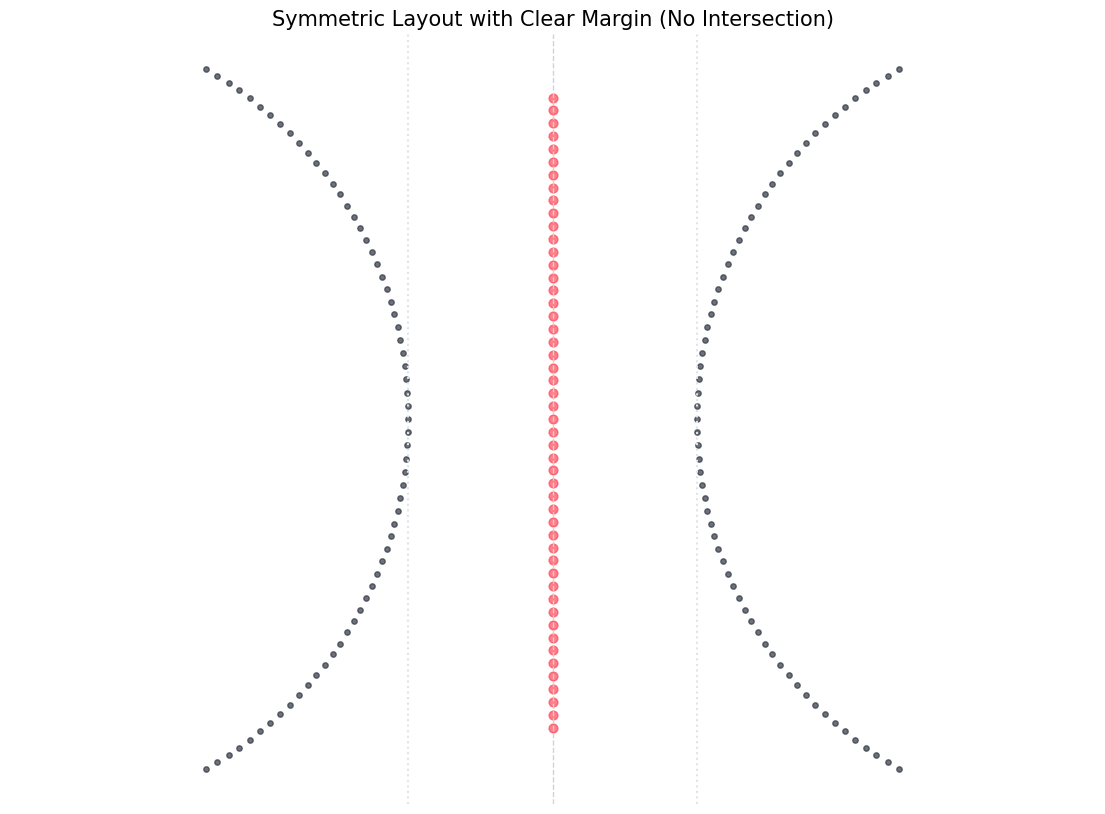

In [4]:
import math
import matplotlib.pyplot as plt

def generate_separated_symmetric_layout(nodes):
    coords = {}
    
    # --- 1. 几何参数设定 ---
    arc_radius = 700           # 较大的半径使弧线更平缓
    arc_span = math.pi / 1.5   # 弧度张角 (约120度)
    horizontal_margin = 250    # 弧线顶点距离中心直线的水平净空间距
    
    # 计算弧线的垂直跨度 (用于决定 Word 长度)
    # y = r * sin(theta)
    arc_vertical_half_height = arc_radius * math.sin(arc_span / 2)
    arc_total_height = 2 * arc_vertical_half_height
    
    # --- 2. Word 节点 (绝对居中直线) ---
    word_nodes = sorted([n for n in nodes if n['type'] == 'word'], key=lambda x: x['degree'], reverse=True)
    num_words = len(word_nodes)
    
    # 长度为弧线垂直跨度的 90%
    target_word_height = arc_total_height * 0.9
    word_y_gap = target_word_height / (num_words - 1) if num_words > 1 else 0

    for i, node in enumerate(word_nodes):
        # 度数最高的在中心，向两端扩散
        rank = (i + 1) // 2
        direction = 1 if i % 2 != 0 else -1
        if i == 0: direction = 0
        
        # X轴固定在0
        coords[node['id']] = (0, round(rank * direction * word_y_gap, 2))

    # --- 3. Song 节点 (两侧远距离弧线) ---
    song_nodes = [n for n in nodes if n['type'] == 'song']
    mid_idx = len(song_nodes) // 2
    song_groups = [song_nodes[:mid_idx], song_nodes[mid_idx:]]
    
    # 配置说明：
    # 右侧弧：圆心在 (margin + radius), 坐标计算用 center - radius * cos(angle) 使开口向左
    # 左侧弧：圆心在 (-margin - radius), 坐标计算用 center + radius * cos(angle) 使开口向右
    side_configs = [
        {"c_x": horizontal_margin + arc_radius, "dir": -1, "label": "Right Arc"},
        {"c_x": -horizontal_margin - arc_radius, "dir": 1, "label": "Left Arc"}
    ]

    for col_idx, col_items in enumerate(song_groups):
        conf = side_configs[col_idx]
        num_in_col = len(col_items)
        
        for row_idx, node in enumerate(col_items):
            # 从上到下均匀分布角度
            angle = (arc_span / 2) - (row_idx / (num_in_col - 1)) * arc_span if num_in_col > 1 else 0
            
            # 计算 X: 圆心 + 方向 * (半径 * cos(角度))
            # 这样保证了弧线的顶点（angle=0时）正好落在 +/-horizontal_margin 上
            x = conf["c_x"] + conf["dir"] * (arc_radius * math.cos(angle))
            y = arc_radius * math.sin(angle)
            coords[node['id']] = (round(x, 2), round(y, 2))
            
    return coords

# --- 运行与绘图 ---
test_nodes = [{'id': f'W{i}', 'type': 'word', 'degree': 100-i} for i in range(50)] + \
             [{'id': f'S{i}', 'type': 'song', 'degree': 5} for i in range(130)]

pos = generate_separated_symmetric_layout(test_nodes)

plt.figure(figsize=(14, 10))
# 绘制节点
for n in test_nodes:
    cid = n['id']
    color = '#ff4757' if n['type'] == 'word' else '#2f3542'
    size = 40 if n['type'] == 'word' else 15
    plt.scatter(pos[cid][0], pos[cid][1], c=color, s=size, alpha=0.7)

# 标注 Word 核心对齐线
plt.axvline(x=0, color='#ced4da', linestyle='--', linewidth=1, label="Word Axis")
# 标注净空间距辅助线
plt.axvline(x=250, color='#dfe4ea', linestyle=':', label="Safety Margin")
plt.axvline(x=-250, color='#dfe4ea', linestyle=':')



plt.title("Symmetric Layout with Clear Margin (No Intersection)", fontsize=15)
plt.axis('equal')
plt.axis('off')
plt.show()

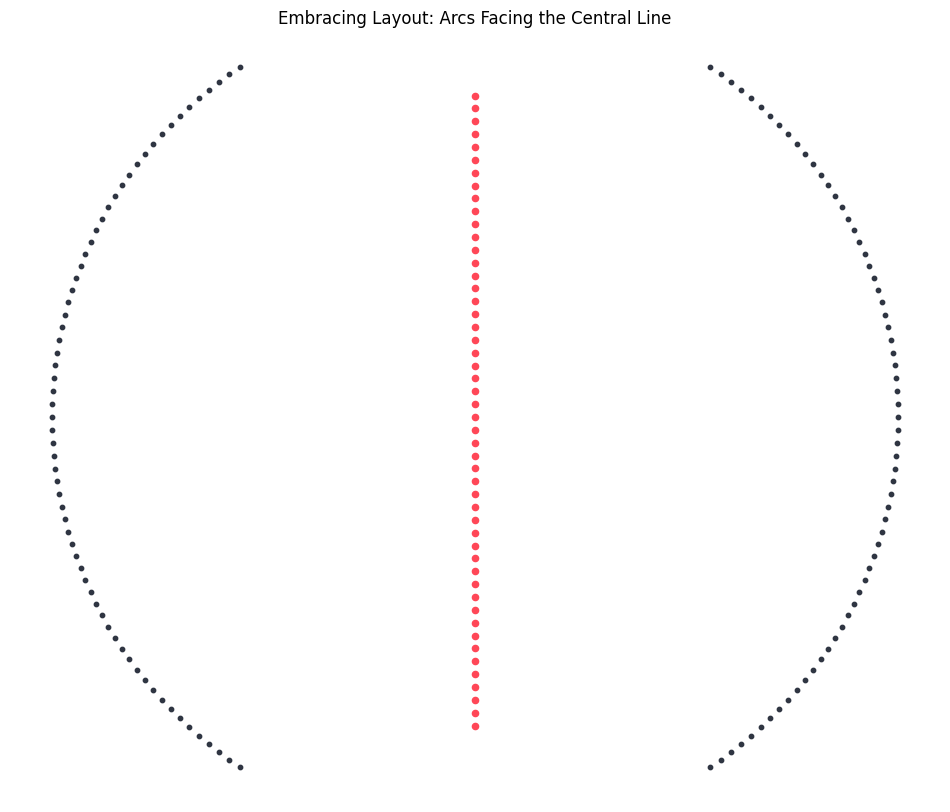

In [132]:
import math
import matplotlib.pyplot as plt

def generate_embracing_layout(nodes):
    coords = {}
    
    # --- 1. 几何参数设定 ---
    arc_radius = 800           # 半径
    arc_span = math.pi / 1.6   # 弧度张角 (约112度)
    # 弧开口端点距离中心直线的水平间距
    horizontal_gap = 300       
    
    # 计算弧线端点的 Y 轴跨度 (用于对齐 Word)
    # y = r * sin(theta)
    arc_half_height = arc_radius * math.sin(arc_span / 2)
    arc_total_height = 2 * arc_half_height
    
    # --- 2. Word 节点 (居中直线) ---
    word_nodes = sorted([n for n in nodes if n['type'] == 'word'], key=lambda x: x['degree'], reverse=True)
    num_words = len(word_nodes)
    
    # 长度为弧垂直跨度的 90%
    target_word_height = arc_total_height * 0.9
    word_y_gap = target_word_height / (num_words - 1) if num_words > 1 else 0

    for i, node in enumerate(word_nodes):
        # 中心扩散排序
        rank = (i + 1) // 2
        direction = 1 if i % 2 != 0 else -1
        if i == 0: direction = 0
        coords[node['id']] = (0, round(rank * direction * word_y_gap, 2))

    # --- 3. Song 节点 (开口向内的对称弧线) ---
    song_nodes = [n for n in nodes if n['type'] == 'song']
    mid_idx = len(song_nodes) // 2
    song_groups = [song_nodes[:mid_idx], song_nodes[mid_idx:]]
    
    # 配置说明：
    # 为了让开口面向直线 (x=0)：
    # 左侧弧的圆心要在右侧，x 坐标为 (horizontal_gap + radius * cos(half_span))
    # 右侧弧的圆心要在左侧，x 坐标为 -(horizontal_gap + radius * cos(half_span))
    
    # 计算圆心位置，使得弧的端点正好落在 horizontal_gap 线上
    edge_x_offset = arc_radius * math.cos(arc_span / 2)
    center_x_pos = horizontal_gap + edge_x_offset

    side_configs = [
        {"c_x": 0, "dir": 1, "name": "Right"}, # 右侧弧，圆心在左，向右弯
        {"c_x": 0, "dir": -1, "name": "Left"}   # 左侧弧，圆心在右，向左弯
    ]

    for col_idx, col_items in enumerate(song_groups):
        conf = side_configs[col_idx]
        num_in_col = len(col_items)
        
        for row_idx, node in enumerate(col_items):
            # 角度分布
            angle = (arc_span / 2) - (row_idx / (num_in_col - 1)) * arc_span if num_in_col > 1 else 0
            
            # 计算 X: 圆心 + 方向 * (半径 * cos(角度))
            x = conf["c_x"] + conf["dir"] * (arc_radius * math.cos(angle))
            y = arc_radius * math.sin(angle)
            coords[node['id']] = (round(x, 2), round(y, 2))
            
    return coords

# --- 运行测试 ---
test_nodes = [{'id': f'W{i}', 'type': 'word', 'degree': 100-i} for i in range(50)] + \
             [{'id': f'S{i}', 'type': 'song', 'degree': 5} for i in range(130)]

pos = generate_embracing_layout(test_nodes)

# --- 绘图 ---
plt.figure(figsize=(12, 10))
for n in test_nodes:
    cid = n['id']
    color = '#ff4757' if n['type'] == 'word' else '#2f3542'
    plt.scatter(pos[cid][0], pos[cid][1], c=color, s=20 if n['type']=='word' else 10)

plt.title("Embracing Layout: Arcs Facing the Central Line")
plt.axis('equal')
plt.axis('off')
plt.show()

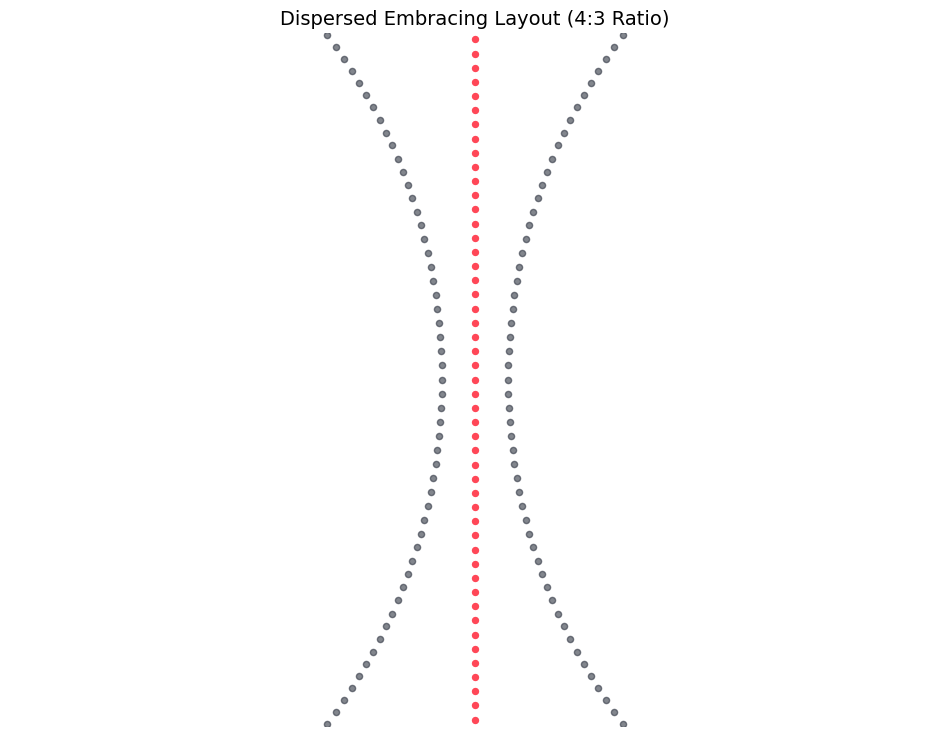

In [127]:
import math
import matplotlib.pyplot as plt

def generate_dispersed_embracing_layout(nodes):
    coords = {}
    
    # --- 1. 画布与几何参数设定 ---
    # 设定画布参考尺寸 (1200 x 900 对应 4:3)
    canvas_w, canvas_h = 1200, 900
    
    # 增加半径使弧线更平缓，节点分布更均匀
    arc_radius = 1000           
    # 减小张角 (约 90 度)，防止弧线两端过于卷曲，使节点在纵向上更分散
    arc_span = math.pi / 2.0    
    
    # 利用 4:3 的宽度，增大水平间距
    horizontal_gap = 350       
    
    # 计算弧线端点的 Y 轴跨度
    arc_half_height = arc_radius * math.sin(arc_span / 2)
    arc_total_height = 2 * arc_half_height
    
    # --- 2. Word 节点 (居中直线) ---
    word_nodes = sorted([n for n in nodes if n['type'] == 'word'], key=lambda x: x['degree'], reverse=True)
    num_words = len(word_nodes)
    
    # 长度设为弧垂直跨度的 85%，留出更多顶部和底部空间
    target_word_height = arc_total_height * 0.85
    word_y_gap = target_word_height / (num_words - 1) if num_words > 1 else 0

    for i, node in enumerate(word_nodes):
        # 中心扩散排序：度数最高的在 (0,0)
        rank = (i + 1) // 2
        direction = 1 if i % 2 != 0 else -1
        if i == 0: direction = 0
        coords[node['id']] = (0, round(rank * direction * word_y_gap, 2))

    # --- 3. Song 节点 (开口向内的对称弧线) ---
    song_nodes = [n for n in nodes if n['type'] == 'song']
    # 130个节点平均分两组
    mid_idx = len(song_nodes) // 2
    song_groups = [song_nodes[:mid_idx], song_nodes[mid_idx:]]
    
    # 计算圆心位置，使弧的开口端点对齐 horizontal_gap
    edge_x_offset = arc_radius * math.cos(arc_span / 2)
    center_x_pos = horizontal_gap + edge_x_offset

    side_configs = [
        {"c_x": -center_x_pos, "dir": 1},  # 右侧弧
        {"c_x": center_x_pos, "dir": -1}   # 左侧弧
    ]

    for col_idx, col_items in enumerate(song_groups):
        conf = side_configs[col_idx]
        num_in_col = len(col_items)
        
        for row_idx, node in enumerate(col_items):
            # 增加随机微调 (jitter) 可以让节点显得更自然，这里保持几何整齐
            angle = (arc_span / 2) - (row_idx / (num_in_col - 1)) * arc_span if num_in_col > 1 else 0
            
            x = conf["c_x"] + conf["dir"] * (arc_radius * math.cos(angle))
            y = arc_radius * math.sin(angle)
            coords[node['id']] = (round(x, 2), round(y, 2))
            
    return coords

# --- 运行测试 ---
test_nodes = [{'id': f'W{i}', 'type': 'word', 'degree': 100-i} for i in range(50)] + \
             [{'id': f'S{i}', 'type': 'song', 'degree': 5} for i in range(130)]

pos = generate_dispersed_embracing_layout(test_nodes)

# --- 4:3 画布绘图 ---
plt.figure(figsize=(12, 9)) # 12:9 即 4:3
for n in test_nodes:
    cid = n['id']
    if n['type'] == 'word':
        plt.scatter(pos[cid][0], pos[cid][1], c='#ff4757', s=40, edgecolors='white', zorder=3)
    else:
        plt.scatter(pos[cid][0], pos[cid][1], c='#2f3542', s=20, alpha=0.6, zorder=2)

# 设置显示范围以适应 4:3
plt.xlim(-800, 800)
plt.ylim(-600, 600)
plt.title("Dispersed Embracing Layout (4:3 Ratio)", fontsize=14)
plt.axis('off')
plt.show()

## 